# Which Meats Will See Rising Demand? Pork, Beef, Chicken, Sheep & Goat

**Question:** Across animal proteins — pork, beef, chicken, and sheep/goat (FAO reports lamb,
mutton, and goat as one category) — which are on a rising demand path, in the US and globally?

**Why consumption alone isn't demand.** Eating more of a meat doesn't prove demand grew — people
also buy more when the price falls. Following the approach used in the Kansas State University
meat demand indices, we call it a *demand increase* only when consumption grows **after
adjusting for what the price did**, using standard own-price elasticities from the ag-economics
literature.

**Data:**
- Per-capita consumption (kg/person/year), 1961–2023: FAO Food Balance Sheets via Our World in Data
- US retail prices and CPI, 1997–present: BLS average price series
- Growth-rate comparison across countries to locate where sheep/goat demand actually lives

**Plan:**
1. Consumption trends, US vs world
2. Price-adjusted demand index for US beef, pork, chicken
3. Trend forecasts to 2035 (Holt exponential smoothing with damped trend)
4. Verdict by species

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_fetch import fetch_owid_consumption, fetch_bls_prices

sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cons = fetch_owid_consumption()    # entity, year, meat, kg_per_capita
retail = fetch_bls_prices()        # monthly retail $/lb + CPI

MEAT_LABEL = {
    "chicken_poultry": "Poultry",
    "beef": "Beef",
    "pork": "Pork",
    "sheep_goat": "Sheep & goat (lamb/mutton/goat)",
}
MEAT_COLOR = {
    "chicken_poultry": "tab:orange",
    "beef": "tab:red",
    "pork": "tab:pink",
    "sheep_goat": "tab:green",
}

us = cons[cons["entity"] == "United States"].pivot(index="year", columns="meat", values="kg_per_capita")
world = cons[cons["entity"] == "World"].pivot(index="year", columns="meat", values="kg_per_capita")
print(f"US sample: {us.index.min()}-{us.index.max()}   World sample: {world.index.min()}-{world.index.max()}")
us.tail(3).round(1)

US sample: 1961-2023   World sample: 1961-2023


meat,beef,chicken_poultry,pork,sheep_goat
year,,,,
2021,37.4,52.3,29.5,0.7
2022,37.7,53.8,29.6,0.7
2023,37.0,54.5,29.1,0.6


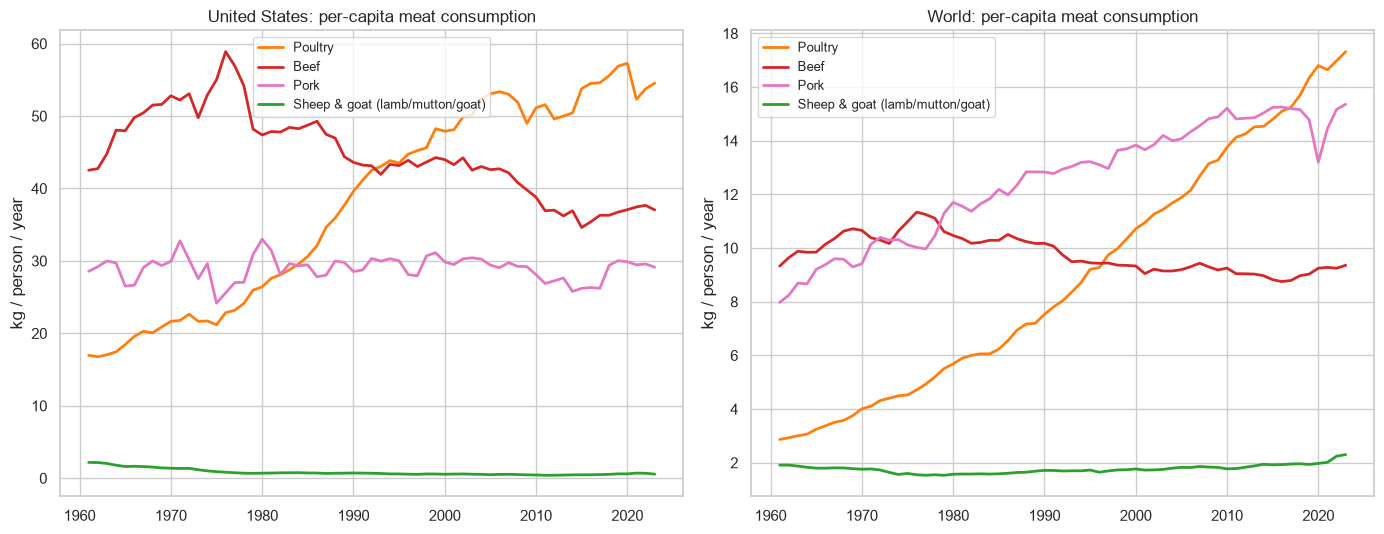

,US 20y CAGR %,US 10y CAGR %,World 20y CAGR %,World 10y CAGR %
meat,,,,
Poultry,0.42,0.87,2.10,1.78
Beef,-0.69,0.22,0.12,0.36
Pork,-0.22,0.53,0.39,0.33
Sheep & goat (lamb/mutton/goat),0.13,2.68,1.38,2.05


In [2]:
# --- 1. Consumption trends: US vs world -------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
for ax, (df, title) in zip(axes, [(us, "United States"), (world, "World")]):
    for meat in MEAT_LABEL:
        if meat in df.columns:
            ax.plot(df.index, df[meat], label=MEAT_LABEL[meat], color=MEAT_COLOR[meat], lw=2)
    ax.set_title(f"{title}: per-capita meat consumption")
    ax.set_ylabel("kg / person / year")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_consumption_trends.png", dpi=150, bbox_inches="tight")
plt.show()

# Compound annual growth rates over the last 10 and 20 years of data
def cagr(series, years):
    s = series.dropna()
    end_y = s.index.max()
    start_y = end_y - years
    if start_y not in s.index or s[start_y] <= 0:
        return np.nan
    return ((s[end_y] / s[start_y]) ** (1 / years) - 1) * 100

rows = []
for meat in MEAT_LABEL:
    rows.append({
        "meat": MEAT_LABEL[meat],
        "US 20y CAGR %": cagr(us[meat], 20),
        "US 10y CAGR %": cagr(us[meat], 10),
        "World 20y CAGR %": cagr(world[meat], 20),
        "World 10y CAGR %": cagr(world[meat], 10),
    })
growth = pd.DataFrame(rows).set_index("meat").round(2)
growth

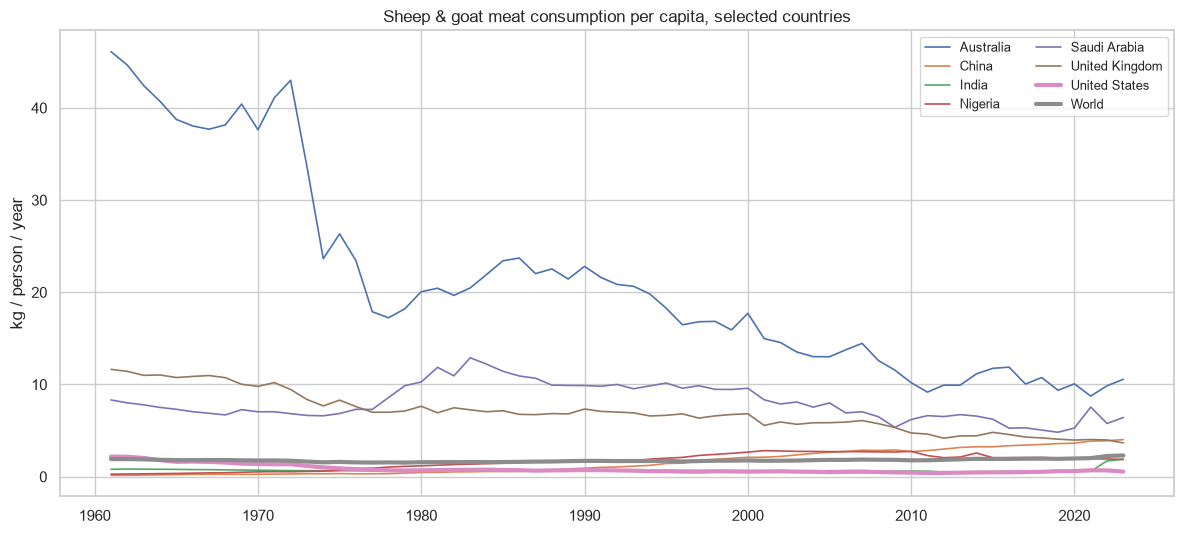

Latest per-capita sheep/goat consumption (kg/yr):
entity
Australia         10.56
Saudi Arabia       6.42
China              4.02
United Kingdom     3.66
World              2.30
India              1.89
Nigeria            1.87
United States      0.56
Name: kg_per_capita, dtype: float64


In [3]:
# --- Where does sheep & goat demand actually live? ---------------------------
# The US eats very little lamb/mutton/goat; the growth story is elsewhere.
focus = ["United States", "China", "India", "Nigeria", "Saudi Arabia", "Australia",
         "United Kingdom", "World"]
sg = cons[(cons["meat"] == "sheep_goat") & (cons["entity"].isin(focus))]

fig, ax = plt.subplots(figsize=(12, 5.5))
for entity, grp in sg.groupby("entity"):
    lw = 3 if entity in ("United States", "World") else 1.2
    ax.plot(grp["year"], grp["kg_per_capita"], label=entity, lw=lw)
ax.set_ylabel("kg / person / year")
ax.set_title("Sheep & goat meat consumption per capita, selected countries")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_sheep_goat_countries.png", dpi=150, bbox_inches="tight")
plt.show()

latest = sg.loc[sg.groupby("entity")["year"].idxmax()].set_index("entity")
print("Latest per-capita sheep/goat consumption (kg/yr):")
print(latest["kg_per_capita"].sort_values(ascending=False).round(2))

## 2. Price-adjusted demand index (US)

The demand index asks: *given how consumption changed, did prices behave the way a fixed demand
curve would predict?* If people ate **more** beef in a year when real beef prices **rose**, the
demand curve must have shifted outward.

Mechanics (per year, per meat):

1. Compute the % change in per-capita consumption \( \%\Delta Q \).
2. On an *unchanged* demand curve with own-price elasticity \( \varepsilon \), that quantity
   change should have required a price change of \( \%\Delta P^{exp} = \%\Delta Q / \varepsilon \).
3. Compare with the *actual* real (CPI-deflated) retail price change. The ratio
   \( (1+\%\Delta P^{act}) / (1+\%\Delta P^{exp}) \) compounds into the demand index.

Elasticities (long-run retail estimates from the ag-econ literature, e.g. Tonsor & Schroeder):
beef −0.50, pork −0.70, chicken −0.60. Results are qualitatively robust to reasonable
alternatives — feel free to change them below and re-run.

Retail price proxies: ground beef (beef), average of bacon and boneless chops (pork), whole
fresh chicken (chicken). No BLS series exists for lamb/goat, so sheep/goat is assessed on
consumption trends and global evidence instead.

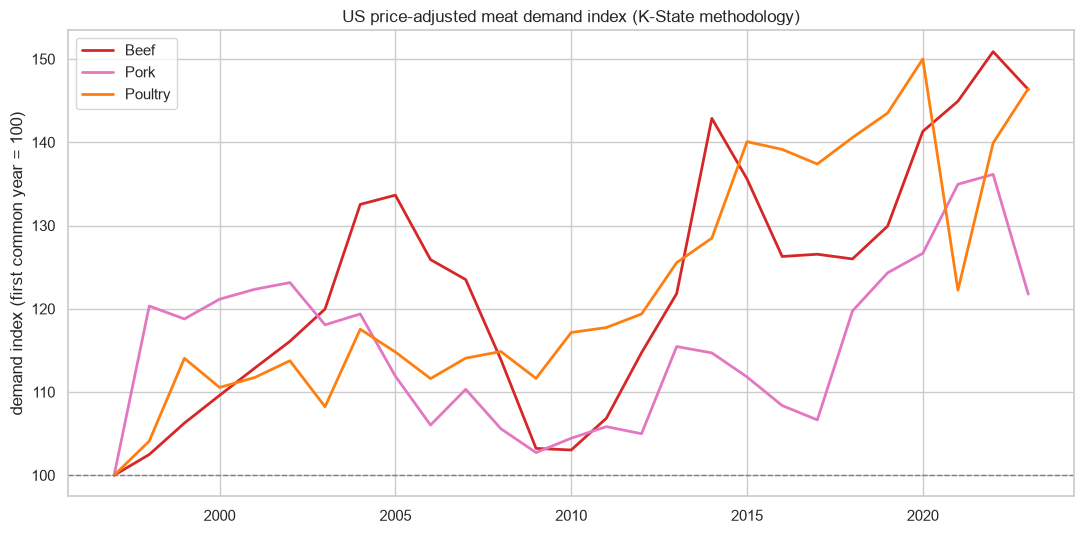

Demand index, latest year (start = 100):
  Poultry                             146
  Beef                                146
  Pork                                122


In [4]:
# --- 2. Demand index computation ---------------------------------------------
ELASTICITY = {"beef": -0.50, "pork": -0.70, "chicken_poultry": -0.60}

annual = retail.resample("YS").mean()
annual.index = annual.index.year
real_price = pd.DataFrame(index=annual.index)
deflator = annual["cpi_all_items"].iloc[-1] / annual["cpi_all_items"]
real_price["beef"] = annual["ground_beef_lb"] * deflator
real_price["pork"] = annual[["bacon_lb", "pork_chops_boneless_lb"]].mean(axis=1) * deflator
real_price["chicken_poultry"] = annual["chicken_whole_lb"] * deflator

def demand_index(meat):
    q = us[meat].dropna()
    p = real_price[meat].dropna()
    years = sorted(set(q.index) & set(p.index))
    idx = pd.Series(index=years, dtype=float)
    idx.iloc[0] = 100.0
    eps = ELASTICITY[meat]
    for i in range(1, len(years)):
        y0, y1 = years[i - 1], years[i]
        dq = q[y1] / q[y0] - 1
        expected_p = 1 + dq / eps          # price move a fixed demand curve would need
        actual_p = p[y1] / p[y0]
        idx[y1] = idx[y0] * (actual_p / expected_p)
    return idx

fig, ax = plt.subplots(figsize=(11, 5.5))
final_vals = {}
for meat in ELASTICITY:
    di = demand_index(meat)
    ax.plot(di.index, di.values, lw=2, color=MEAT_COLOR[meat], label=MEAT_LABEL[meat])
    final_vals[MEAT_LABEL[meat]] = di.dropna().iloc[-1]
ax.axhline(100, color="grey", ls="--", lw=1)
ax.set_ylabel(f"demand index (first common year = 100)")
ax.set_title("US price-adjusted meat demand index (K-State methodology)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "08_demand_index.png", dpi=150, bbox_inches="tight")
plt.show()

print("Demand index, latest year (start = 100):")
for k, v in sorted(final_vals.items(), key=lambda kv: -kv[1]):
    print(f"  {k:<35} {v:.0f}")

## 3. Consumption forecasts to 2035

Holt exponential smoothing with a **damped** trend — a deliberately conservative choice: it
extrapolates the recent trend but lets it flatten rather than run away, which suits slow-moving
dietary variables. This is a trend forecast, not a structural model; it will not anticipate
shocks (disease outbreaks, trade policy) and is best read as "where does the current trajectory
point."

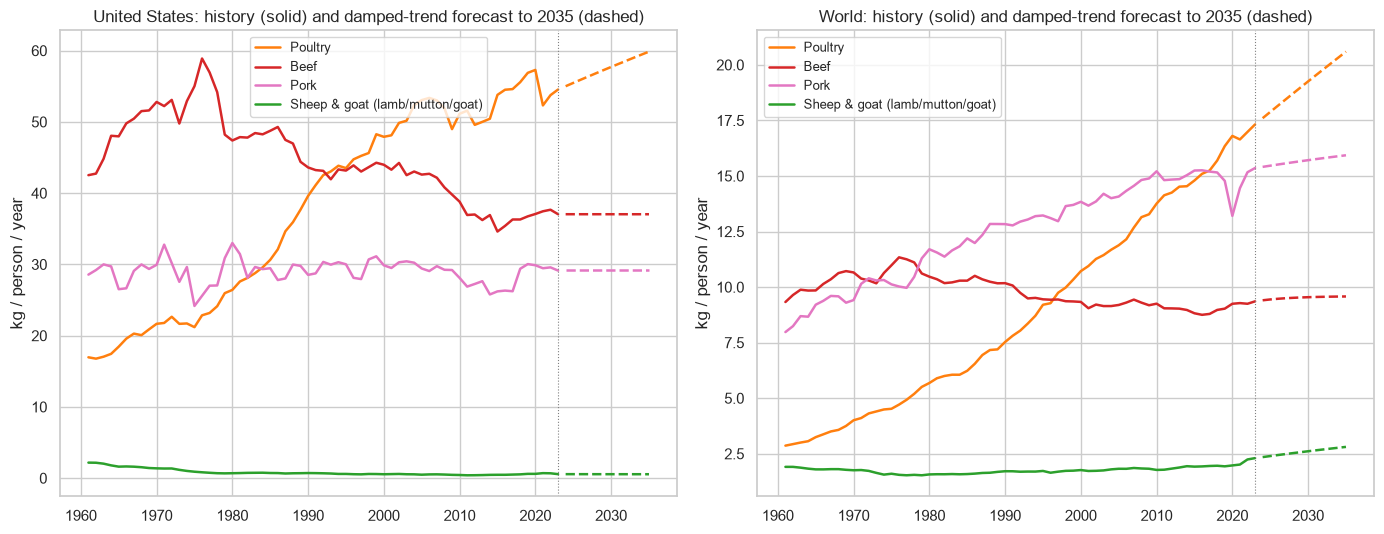

latest (2023)  forecast 2035  \
region        meat                                                            
United States Poultry                                   54.5           59.9   
              Beef                                      37.0           37.0   
              Pork                                      29.1           29.2   
              Sheep & goat (lamb/mutton/goat)            0.6            0.5   
World         Poultry                                   17.3           20.6   
              Beef                                       9.4            9.6   
              Pork                                      15.4           15.9   
              Sheep & goat (lamb/mutton/goat)            2.3            2.8   

                                               implied change %  
region        meat                                               
United States Poultry                                       9.7  
              Beef                                         -0.0  
              Pork                                          0.3  
              Sheep & goat (lamb/mutton/goat)              -2.0  
World         Poultry                                      18.9  
              Beef                                          2.3  
              Pork                                          3.7  
              Sheep & goat (lamb/mutton/goat)              22.0

In [5]:
# --- 3. Holt damped-trend forecasts ------------------------------------------
from statsmodels.tsa.holtwinters import Holt

HORIZON = 2035

def holt_forecast(series):
    s = series.dropna()
    s.index = pd.PeriodIndex(s.index, freq="Y").to_timestamp()
    model = Holt(s, damped_trend=True, initialization_method="estimated").fit(optimized=True)
    steps = HORIZON - s.index[-1].year
    fc = model.forecast(steps)
    fc.index = range(s.index[-1].year + 1, HORIZON + 1)
    return fc

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
forecasts = {}
for ax, (df, title) in zip(axes, [(us, "United States"), (world, "World")]):
    for meat in MEAT_LABEL:
        hist = df[meat].dropna()
        fc = holt_forecast(hist)
        forecasts[(title, meat)] = fc
        ax.plot(hist.index, hist.values, color=MEAT_COLOR[meat], lw=1.8, label=MEAT_LABEL[meat])
        ax.plot(fc.index, fc.values, color=MEAT_COLOR[meat], lw=1.8, ls="--")
    ax.axvline(hist.index.max(), color="grey", lw=0.8, ls=":")
    ax.set_title(f"{title}: history (solid) and damped-trend forecast to {HORIZON} (dashed)")
    ax.set_ylabel("kg / person / year")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

rows = []
for (region, meat), fc in forecasts.items():
    hist_last = (us if region == "United States" else world)[meat].dropna()
    rows.append({
        "region": region, "meat": MEAT_LABEL[meat],
        f"latest ({hist_last.index.max()})": round(hist_last.iloc[-1], 1),
        f"forecast {HORIZON}": round(fc.iloc[-1], 1),
        "implied change %": round((fc.iloc[-1] / hist_last.iloc[-1] - 1) * 100, 1),
    })
pd.DataFrame(rows).set_index(["region", "meat"])

## 4. Verdict by species

| Species | US outlook | Global outlook |
|---|---|---|
| **Chicken/poultry** | **Rising** — consumption growing ~0.9%/yr, demand index +46% since 1997, forecast +10% by 2035 | **Rising fastest** — ~2%/yr for two decades, forecast +19% by 2035 |
| **Beef** | **Demand strong, consumption flat** — demand index +46% since 1997 even though kg/person is flat: people pay ever-higher real prices for the same beef | Slow growth (+2% by 2035) |
| **Pork** | **Flat** — demand index +22%, consumption stable ~29 kg | Modest growth (+4% by 2035) |
| **Sheep & goat (lamb/mutton/goat)** | **Small but turning up** — only 0.6 kg/person, yet 10-yr CAGR is +2.7%, the fastest US growth rate of any category (off a tiny base) | **Second-fastest globally** — forecast +22% per capita by 2035, driven by Asia, the Middle East, and Africa |

**Interpretation:**

- **Chicken is the clearest demand winner** in both the US and the world: growing consumption
  without falling real prices is the definition of an outward demand shift.
- **Beef's story is the most subtle** — US per-capita consumption hasn't grown in 20 years, but
  the *price-adjusted* demand index is up ~46%: consumers keep absorbing record real prices.
  Combined with the historic herd tightness seen in the futures notebook, beef demand is robust
  even as volume stagnates.
- **Pork is the value protein.** Demand growth is positive but lags beef and chicken; with beef
  ~2.5σ expensive relative to hogs (notebook 01), pork has near-term substitution upside.
- **Lamb/mutton/goat is a niche-growth story.** US volumes are tiny (0.6 kg vs 54.5 kg poultry)
  but growing faster in percentage terms than any other meat — consistent with demographic-driven
  demand (Middle Eastern, African, Caribbean, and South Asian cuisines). Globally it is the
  second-fastest growing meat. The US has no futures contract and thin retail price data for it,
  which is itself a market-efficiency observation: a growing market that price discovery
  infrastructure hasn't caught up with.

**Limitations & extensions:** FAO merges sheep and goat (USDA slaughter data could split them);
demand indices use fixed literature elasticities (could be estimated directly with 2SLS);
forecasts are univariate trend models (an income + price + demographics panel model is the
natural next step).